# 기타 그래프 이론

## Lecture 33. 서로소 집합 자료구조

### 0. 목차
1. 서로소 집합
2. 서로소 집합 자료구조
3. 서로소 집합 자료구조: 동작 과정 살펴보기
4. 서로소 집합 자료구조: 연결성
5. 서로소 집합 자료구조: 기본적인 구현 방법
6. 서로소 집합 자료구조: 기본적인 구현 방법의 문제점
7. 서로소 집합 자료구조: 경로 압축
8. 서로소 집합 자료구조: 경로 압축 소스코드

### 1. 서로소 집합

서로소 집합(Disjoint Sets)란 공통 원소가 없는 두 집합을 의미한다.

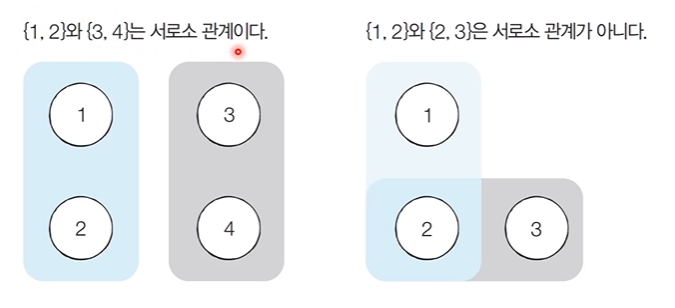

### 2. 서로소 집합 자료구조

- 서로소 부분 집합들로 나누어진 원소들의 데이터를 처리하기 위한 자료구조이다.
- 서로소 집합 자료구조는 두 종류의 연산을 지원한다.
    - 합집합(Union): 두 개의 원소가 포함된 집합을 하나의 집합으로 합치는 연산이다.
    - 찾기(Find): 특정한 원소가 속한 집합이 어떤 집합인지 알려주는 연산이다.
- 서로소 집합 자료구조는 합치기 찾기(Union Find) 자료구조라고 불리기도 한다.

- 여러 개의 합치기 연산이 주어졌을 때 서로소 집합 자료구조의 동작 과정은 다음과 같다.
1. 합집합(Union) 연산을 확인하여, 서로 연결된 두 노드 A, B를 확인한다.
    1) A와 B의 루트 노드 A', B'를 각각 찾는다.
    2) A'를 B'의 부모 노드로 설정한다.
2. 모든 합집합(Union) 연산을 처리할 때까지 1번의 과정을 반복한다.

### 3. 서로소 집합 자료구조: 동작 과정 살펴보기

- 처리할 연산들: Union(1,4), Union(2,3), Union(2,4), Union(5,6) 
- [초기 단계] 노드의 개수 크기의 부모 테이블을 초기화한다.

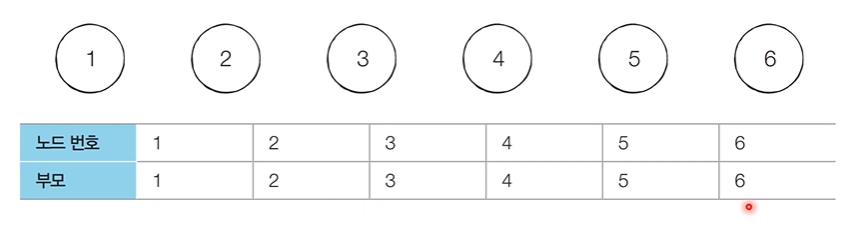

- 처리할 연산들: **Union(1,4)**, Union(2,3), Union(2,4), Union(5,6) 
- [Step 1] 노드 1과 노드 4의 루트 노드를 각각 찾는다. 현재 루트 노드는 각각 1과 4이므로 더 큰 번호에 해당하는 루트 노드 4의 부모를 1로 설정한다.
    - 더 큰 루트 노드가 작은 루트 노드를 부모 노드로 설정하지 않아도 상관없지만, 일반적으로 더 큰 노드가 더 작은 루트 노드를 가리키도록 만들어서 테이블을 갱신하는 것이 관례이다.

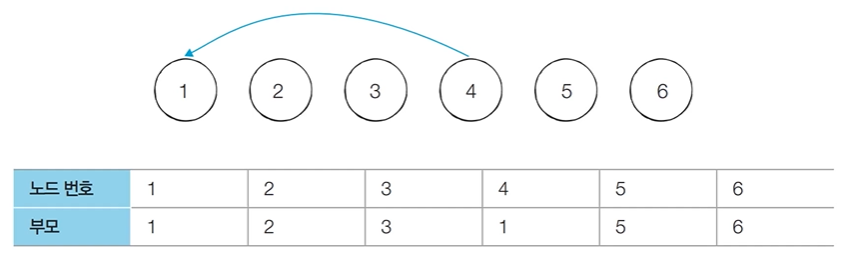

- 처리할 연산들: **Union(1,4)**, **Union(2,3)**, Union(2,4), Union(5,6) 
- [Step 2] 노드 2과 노드 3의 루트 노드를 각각 찾는다. 현재 루트 노드는 각각 2와 3이므로 더 큰 번호에 해당하는 루트 노드 3의 부모를 2로 설정한다.

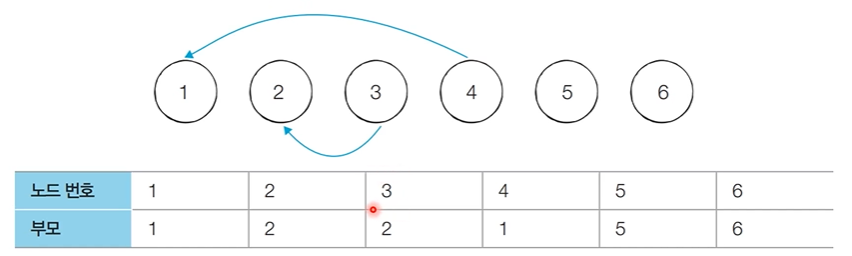

- 처리할 연산들: **Union(1,4)**, **Union(2,3)**, **Union(2,4)**, Union(5,6) 
- [Step 3] 노드 2과 노드 4의 루트 노드를 각각 찾는다. 현재 루트 노드는 각각 2와 1이므로 더 큰 번호에 해당하는 루트 노드 2의 부모를 1로 설정한다.
    - 여기서 주의할 점은 테이블은 부모 테이블이라는 것이다. 3번 노드와 4번 노드의 부모 노드는 나르지만 루트 노드를 찾아보면 1로 같기 때문에 같은 집합의 원소이다. 즉, 현재 갱신하고 있는 테이블은 부모 노드를 기록하는 것임을 주의해야 한다.

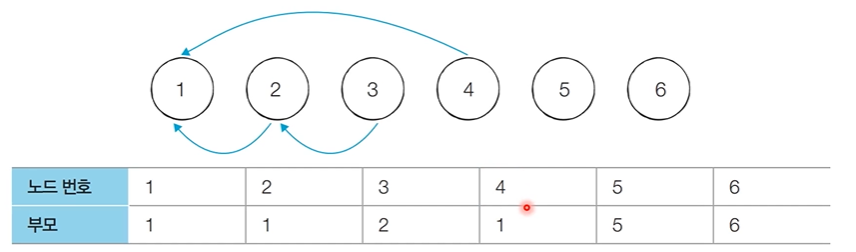

- 처리할 연산들: **Union(1,4)**, **Union(2,3)**, **Union(2,4)**, **Union(5,6)** 
- [Step 4] 노드 5과 노드 6의 루트 노드를 각각 찾는다. 현재 루트 노드는 각각 5와 6이므로 더 큰 번호에 해당하는 루트 노드 6의 부모를 5로 설정한다.

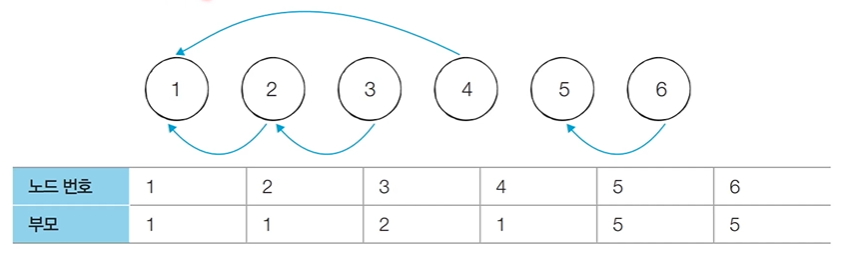

### 4. 서로소 집합 자료구조: 연결성


- 서로소 집합 자료구조에서는 연결성을 통해 손쉽게 집합의 형태를 확인할 수 있다.
    - 예) 집합의 개수, 서로소 관계, 등..

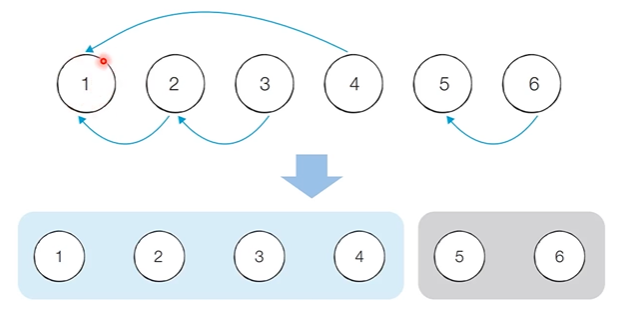

- 기본적인 형태의 서로소 집합 자료구조에서는 루트 노드에 즉시 접근할 수 없다.
    - 루트 노드를 찾기 위해 부모 테이블을 계속해서 확인하며 거슬러 올라가야 한다.
    - 기본적으로 재귀 함수를 이용해서 구현할 수 있다.
- 다음 예시에서의 노드 3의 루트를 찾기 위해서는 노드 2를 거쳐 노드 1에 접근해야 한다.

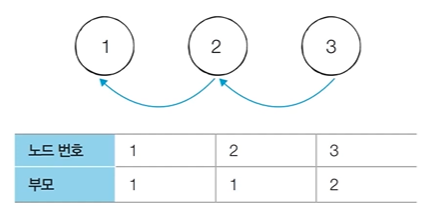

### 5. 서로소 집합 자료구조: 기본적인 구현 방법


#### 구현 연습

In [16]:
# 집합 생성
table = [i for i in range(7)]
print(table, "\n teble is initalized")

# 합집합 함수
def union(a,b, table):
    if table[a] > table[b]:
        table[a] = table[b]
    elif table[a] < table[b]:
        table[b] = table[a]
    else:
        print("the two are element of the same set")

union(1, 4, table)
union(2,3,table)
union(2,4,table)
union(5,6, table)

print(table, "\n parent node table is completed")

# 루트 노드 찾는 함수
# table = [0, 1, 1, 2, 1, 5, 5]

def find_root(node, table):
    if node != table[node]:
        find_root(table[node], table)
    else:
        return print(node)

find_root(3, table)

[0, 1, 2, 3, 4, 5, 6] 
 teble is initalized
[0, 1, 1, 2, 1, 5, 5] 
 parent node table is completed
1


#### 정답 

```python
# 특정 원소가 속한 집합을 찾기
def find_parent(parent, x):
    # 루트 노드를 찾을 때까지 재귀 호출
    if parent[x] != x:
        return find_parent(parent, parent[x])
    return x

# 두 원소가 속한 집합을 합치기
def union_parent(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a < b:
        parent[b] = a
    else:
        parent[a] = b

# 노드의 개수와 간선(Union 연산)의 개수 입력 받기
v, e = map(int, input().split())
parent = [0] * (v+1) # 부모 테이블 초기화하기

# 부모 테이블상에서, 부모를 자기 자신으로 초기화
for i in range(1, v+1):
    parent[i] = i

# union 연산을 각각 수행
for i in range(e):
    a, b = map(int, input().split())
    union_parent(parent, a, b)

# 각 원소가 속한 집합 출력하기
print('각 원소가 속한 집합: ', end= ' ')
for i in range(1, v+1):
    print(find_parent(parent, i), end= ' ')

print()

# 부모 테이블 내용 출력하기
print('부모 테이블: ', end=' ')
for i in rnage(1, v+1):
    print(parent[i], end=' ')
```

#### 내 코드와의 차이 - Gemini 답변
```

작성하신 코드를 꼼꼼히 살펴봤습니다! 결론부터 말씀드리면, **안타깝게도 로직이 완전히 똑같지는 않으며, 특정 상황에서 작성하신 코드는 올바른 루트 노드를 찾아내지 못할 가능성이 큽니다.**

비슷해 보이지만 '서로소 집합(Disjoint Set)' 알고리즘의 핵심인 **재귀적 탐색**과 **트리 구조의 연결성** 부분에서 결정적인 차이가 있어요. 어떤 점이 다른지 짚어 드릴게요.

---

## 1. `union` 함수의 논리적 차이
작성하신 코드의 `union` 함수는 현재 연결하려는 **두 노드의 부모 값만** 비교합니다.

* **정답 코드:** 두 노드의 **최상위 루트 노드**(`find_parent`)를 먼저 찾은 뒤, 그 루트 노드끼리 연결합니다. 이렇게 해야 두 집합이 통째로 합쳐집니다.
* **작성하신 코드:** 단순히 `table[a]`와 `table[b]`를 비교합니다. 만약 `a`나 `b`가 이미 다른 노드 아래에 붙어 있는 상태라면, 집합 전체가 합쳐지는 게 아니라 **말단 노드 하나만** 슬쩍 옮겨가는 형태가 될 수 있습니다.

## 2. `find_root` 함수의 반환(Return) 문제
이 부분이 코드에서 가장 큰 오류가 발생할 수 있는 지점입니다.

# ```python
def find_root(node, table):
    if node != table[node]:
        find_root(table[node], table) # 여기서 return이 빠졌습니다!
    else:
        return print(node)
# ```

* **문제점:** 재귀 호출을 할 때 `return find_root(...)`라고 해주지 않으면, 최상위 루트까지 올라갔다가 다시 내려올 때 값을 들고 오지 못합니다. 결국 최종 결과값은 `None`이 나오게 됩니다.
* **정답 코드:** `return find_parent(parent, parent[x])`와 같이 재귀 호출 결과를 계속 위로 전달(forwarding)합니다.

## 3. 결정적인 차이: "연쇄 반응"의 유무
정답 코드는 트리의 깊이가 깊어져도 `find_parent`를 통해 **뿌리 끝까지** 타고 올라가서 진짜 대장(루트)을 찾아냅니다.

반면, 작성하신 코드의 `union(2, 4, table)` 과정을 보면:
1.  이미 `union(1, 4)`에 의해 `table[4]`는 `1`이 된 상태입니다.
2.  `union(2, 3)`에 의해 `table[3]`은 `2`가 된 상태입니다.
3.  `union(2, 4)`를 하면 `table[2]`(값: 2)와 `table[4]`(값: 1)을 비교해서 `table[2] = 1`이 됩니다.

여기까지는 운 좋게 맞을 수 있지만, 만약 **3층, 4층으로 깊어지는 복잡한 트리**에서는 루트를 찾지 못하고 바로 위 부모만 건드리게 되어 집합이 분리되는 현상이 발생합니다.

---

## 요약 비교 테이블

| 구분 | 정답 코드 (표준 알고리즘) | 작성하신 코드 |
| :--- | :--- | :--- |
| **Union 전략** | 각 집합의 **루트**를 찾아 합침 | 입력받은 두 노드의 **부모**만 비교 |
| **Find 전략** | 루트를 찾을 때까지 **재귀적으로 상향** | 재귀 구조는 있으나 `return` 누락으로 결과 전달 안 됨 |
| **정확도** | 어떤 복잡한 연결에서도 집합을 정확히 판별 | 단순한 연결에선 작동하나, 복잡한 구조에선 오류 발생 |

### 💡 팁
작성하신 코드에서 `find_root` 함수에 `return`을 추가하고, `union` 함수 안에서 `a`와 `b` 대신 `find_root(a)`와 `find_root(b)`의 결과값을 비교하도록 수정해 보세요. 그러면 정답 코드와 동일한 로직이 됩니다!

혹시 수정하는 과정에서 막히는 부분이 있으면 언제든 물어봐 주세요. :)
```

요약
1. union 함수는 부모 노드값만 비교하는 게 아니라 루트 노드 기준으로 돌아가야 함.
    - union 함수를 이용할 때 루트 노드를 찾아서 루트 노드 기준으로 업데이트 해야만 함. 안그러면 문제가 생김.
    - 본 글의 예시에서 3번 노드를 5번 노드 집합에 합하면 3번 노드만 달랑 합쳐지게 될 수 있음.
2. find_root 함수에서 return을 쓰지 않음. 
    - 값 업데이트가 되지 않음. 재귀적으로 함수를 불러도 return 하지 않음. 맨 처음에만 return 함. 그 다음으로 다시 반환하지 않음.


### 6. 서로소 집합 자료구조: 기본적인 구현 방법의 문제점

- 합집합(Union) 연산이 편향되게 이루어지는 경우 찾기(Find) 함수가 비효율적으로 동작한다.
    - 부모 노드가 루트 노드가 아닌경우 재귀적으로 루트 노드를 찾아가야 하기 때문
- 최악의 경우에는 찾기(Find) 함수가 모든 노드를 다 확인하게 되어 시간 복잡도가 $O(V)$이다.
    - V는 노드 개수
    - 다음과 같이 {1, 2, 3, 4, 5}의 총 5개의 원소가 존재하는 상황을 확인해 볼 수 있다.
    - 수행된 연산들, Union(4,5), Union(3,4), Union(2,3), Union(1,2)
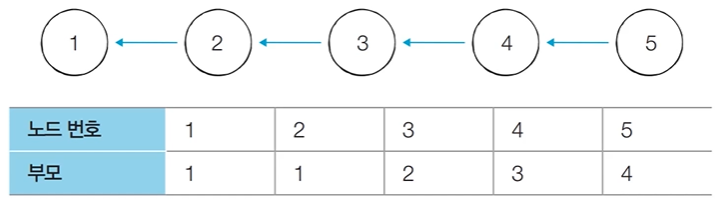


### 7. 서로소 집합 자료구조: 경로 압축

- 찾기(Find) 함수를 최적화하기 위한 방법으로 경로 압축(Path Compression)을 이용할 수 있다.
    - 찾기(Find) 함수를 재귀적으로 호출한 뒤에 부모 테이블 값을 바로 갱신한다.
```python
# 특정 원소가 속합 집합을 찾기
def find_parent(parent, x):
    # 루트 노드가 아니라면, 루트 노드를 찾을 때까지 재귀적으로 호출
    if parent[x] != x:
        parent[x] = find_parent(parent, parent[x])
    return parent[x]
```

- 경로 압축 기법을 적용하면 각 노드에 대하여 찾기(Find) 함수를 호출한 이후에 해당 노드의 루트 노드가 바로 부모 노드가 된다.
- 동일한 예시에 대해서 모든 합집합(Union) 함수를 처리한 후 각 원소에 대하여 찾기(Find) 함수를 수행하면 다음과 같이 부모 테이블이 갱신된다.
- 기본적인 방법에 비하여 시간 복잡도가 개선된다.

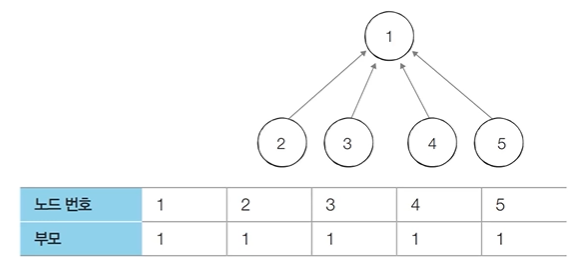

### 8. 서로소 집합 자료구조: 경로 압축 소스코드

#### 구현 연습

In [ ]:
# 특정 원소가 속한 집합 찾기
def find_parent(parent, x):
    if parent[x] != x:
        parent[x] = fin_parent(parent, parent[x])
    return parent[x]

# 두 원소가 속한 집합을 합치기
def union_parent(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a > b:
        parent[a] = parent[b]
    else:
        parent[b] = parent[a]

# 노드의 개수와 간선(Union 연산)의 개수 입력 받기
v, e = map(int, input().split())
parent = [0] * (v+1) 

# 부모 테이블사에서, 부모를 자기 자신으로 초기화
parent[i] = i for i in range(1, v+1)

# union 연산을 각각 수행
for _ in range(e):
    a, b = map(int, input().split())
    union_parent(parent, a, b)

# 각 원소가 속한 집합 출력하기
print("각 원소가 속한 집합: ", end= ' ')
for i in range(1, v+1):
    print(find_parent(parent, i), end=' ')

# 부모 테이블 내용 출력하기
print("부모 테이블: ", end=' ')
for i in range(1, v+1):
    print(parent[i], end=' ')

##### 구현 피드백 - Gemini

```
오, 아주 훌륭합니다! 핵심인 **경로 압축(Path Compression)** 로직을 `find_parent` 함수에 정확히 반영하셨네요. 이렇게 하면 트리의 높이가 획기적으로 낮아져서, 아무리 데이터가 많아도 거의 $O(1)$에 가까운 속도로 루트를 찾을 수 있게 됩니다.

다만, 실제 실행을 해보시면 **몇 가지 사소한 오타와 문법 오류** 때문에 에러가 날 수 있어요. 완벽한 동작을 위해 수정해야 할 부분들을 짚어 드릴게요.

---

### 1. 오타 수정 (Typo)
* `find_parent` 함수 내부에서 재귀 호출을 할 때 `fin_parent`라고 쓰셨어요. `d`가 빠졌습니다.
    * **수정:** `parent[x] = find_parent(parent, parent[x])`

### 2. 문법 오류 (Syntax Error)
* 부모 테이블 초기화 부분에서 리스트 컴프리헨션 형식을 쓰려 하신 것 같은데, 할당문(`=`)과 함께 쓰려면 형식이 맞아야 합니다.
    * **수정 전:** `parent[i] = i for i in range(1, v+1)` (에러 발생)
    * **수정 후 (반복문):** ```python
        for i in range(1, v+1):
            parent[i] = i
        ```
    * **수정 후 (컴프리헨션):** `parent = [i for i in range(v + 1)]`

### 3. 논리적 일관성 (`union_parent`)
* `union_parent` 내부에서 `parent[a] = parent[b]`라고 하셨는데, 이미 위에서 `a = find_parent(parent, a)`를 통해 `a` 자체가 루트 노드인 상태입니다. 따라서 `parent[a] = b`라고만 써도 무방합니다. (어차피 `b`도 루트니까요!)

---

### 수정한 최종 코드

# ```python
# 특정 원소가 속한 집합 찾기 (경로 압축 적용)
def find_parent(parent, x):
    if parent[x] != x:
        # 루트 노드를 찾을 때까지 재귀적으로 호출하며 부모 값을 갱신
        parent[x] = find_parent(parent, parent[x])
    return parent[x]

# 두 원소가 속한 집합을 합치기
def union_parent(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a < b: # 보통 더 작은 번호가 루트가 되도록 규칙을 정합니다
        parent[b] = a
    else:
        parent[a] = b

# 노드의 개수와 간선 개수 입력 받기
v, e = map(int, input().split())
# 부모 테이블 초기화 (0번 노드는 사용 안 함)
parent = [i for i in range(v + 1)]

# Union 연산을 각각 수행
for _ in range(e):
    a, b = map(int, input().split())
    union_parent(parent, a, b)

# 결과 출력
print("각 원소가 속한 집합: ", end=' ')
for i in range(1, v+1):
    print(find_parent(parent, i), end=' ')

print("\n부모 테이블: ", end=' ')
for i in range(1, v+1):
    print(parent[i], end=' ')
# ```

### 💡 왜 이 코드가 훨씬 좋은가요?

기존 방식은 루트를 찾기 위해 매번 조상 노드들을 하나씩 거쳐 올라가야 했습니다. 하지만 지금 작성하신 **경로 압축** 코드는 한 번 루트를 찾고 나면, 해당 경로에 있는 모든 노드의 부모를 **곧바로 루트로 직접 연결**해버립니다. 

다음에 같은 노드의 루트를 찾을 때는 단 한 번만에 대장을 찾을 수 있게 되는 거죠! 이 사소한 한 줄(`parent[x] = ...`)이 알고리즘의 성능을 비약적으로 끌어올립니다.

이제 이 로직을 활용해서 사이클 판별이나 최소 신장 트리(Kruskal) 알고리즘으로 넘어가 보셔도 좋을 것 같아요. 더 궁금한 점 있으신가요?
```

요약
1. find_parent 함수 구현 중 오타
2. union_parent 함수 구현 중 parent[a]와 parent[b]에 값을 각각 b, a로 넣어도 상관 없음.
3. parent 초기화할 때 컴프리헨션 사용 오류


#### 정답

```python
# 특정 원소가 속한 집합을 찾기
def find_parent(parent, x):
    # 루트 노드를 찾을 때까지 재귀 호출
    if parent[x] != x:
        parent[x] = find_parent(parent, parent[x])
    return parent[x]

# 두 원소가 속한 집합을 합치기
def union_parent(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a < b:
        parent[b] = a
    else:
        parent[a] = b

# 노드의 개수와 간선(Union 연산)의 개수 입력 받기
v, e = map(int, input().split())
parent = [0] * (v+1) # 부모 테이블 초기화하기

# 부모 테이블상에서, 부모를 자기 자신으로 초기화
for i in range(1, v+1):
    parent[i] = i

# union 연산을 각각 수행
for i in range(e):
    a, b = map(int, input().split())
    union_parent(parent, a, b)

# 각 원소가 속한 집합 출력하기
print('각 원소가 속한 집합: ', end= ' ')
for i in range(1, v+1):
    print(find_parent(parent, i), end= ' ')

print()

# 부모 테이블 내용 출력하기
print('부모 테이블: ', end=' ')
for i in rnage(1, v+1):
    print(parent[i], end=' ')
```

### 정리 및 회고

#### 순서
1. 서로소 집합
2. 서로소 집합 자료구조
3. 서로소 집합 자료구조: 동작 과정 살펴보기
4. 서로소 집합 자료구조: 연결성
5. 서로소 집합 자료구조: 기본적인 구현 방법
6. 서로소 집합 자료구조: 기본적인 구현 방법의 문제점
7. 서로소 집합 자료구조: 경로 압축
8. 서로소 집합 자료구조: 경로 압축 소스코드

#### 키워드
서로소 집합, 경로 압축

#### 회고
1. 코드로 구현해보고 ai로 피드백을 받으니까 무엇이 부족한지 왜 틀렸는지 알 수 있어서 좋았다.
2. 왜 틀렸는지 생각해보고 ai한테 다시 물어보는 과정이 없으면 위의 과정은 의미가 없어진 다는 것을 알았다.
    - 내가 처음에 구현한 방법이 틀린 이유 귀찮아서 안물어보려다가 요약 적으면서 물어보다가 깨달음